In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Loading Dataset

In [3]:
df = pd.read_csv('dataset.csv')   

print(f' Dataset loaded successfully')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

 Dataset loaded successfully
Shape: 8576 rows × 10 columns


,Country,State,Year,Region-Wise Installation Of Electricity,"Energy Value Type (Potential, Capacity, Generation)",Types Of Energy Sources,Nature Of Energy Sources,"Types Of Usage (Utility ,Captive)",Type Of Energy Sector,"Values For Renewable Electricity (UOM:MW(MegaWatt)), Scaling Factor:1"
0,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Capacity,SMALL HYDRO,NaN,NaN,NaN,5.25
1,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Capacity,SOLAR,NaN,NaN,NaN,12.19
2,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Potential,SMALL HYDRO,RENEWABLE,NaN,NaN,7.27
3,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Potential,WIND,RENEWABLE,NaN,NaN,1277.00
4,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",NaN,Generation,BIOMASS-BAGASSE,RENEWABLE,UTILITY,UTILITY-RE,0.00


# Data Overview

In [4]:
print('SHAPE')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')


SHAPE
Rows: 8576, Columns: 10


In [5]:
df.describe()

,"Values For Renewable Electricity (UOM:MW(MegaWatt)), Scaling Factor:1"
count,8576.00
mean,2589.54
std,8675.70
min,0.00
25%,0.00
50%,36.11
75%,1022.08
max,142560.00


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8576 entries, 0 to 8575
Data columns (total 10 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Country                                                                8576 non-null   str    
 1   State                                                                  8576 non-null   str    
 2   Year                                                                   8576 non-null   str    
 3   Region-Wise Installation Of Electricity                                1792 non-null   str    
 4   Energy Value Type (Potential, Capacity, Generation)                    8576 non-null   str    
 5   Types Of Energy Sources                                                8576 non-null   str    
 6   Nature Of Energy Sources                                               7467 non-null   str    
 7  

# Renaming Columns

In [7]:
df.columns = [
    'Country',
    'State',
    'Year',
    'Region',
    'Value_Type',       
    'Energy_Source',    
    'Nature',           
    'Usage_Type',       
    'Sector',           
    'Value_MW'          
]

print('Columns renamed:')
print(df.columns.tolist())
df.head(3)

Columns renamed:
['Country', 'State', 'Year', 'Region', 'Value_Type', 'Energy_Source', 'Nature', 'Usage_Type', 'Sector', 'Value_MW']


,Country,State,Year,Region,Value_Type,Energy_Source,Nature,Usage_Type,Sector,Value_MW
0,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Capacity,SMALL HYDRO,NaN,NaN,NaN,5.25
1,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Capacity,SOLAR,NaN,NaN,NaN,12.19
2,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Potential,SMALL HYDRO,RENEWABLE,NaN,NaN,7.27


# Drop Useless Column

In [8]:
print('Unique values in Country column:', df['Country'].unique())

df.drop(columns=['Country'], inplace=True)


Unique values in Country column: <StringArray>
['India']
Length: 1, dtype: str


# Checking Missing Values

In [9]:
df.isna().sum()

State               0
Year                0
Region           6784
Value_Type          0
Energy_Source       0
Nature           1109
Usage_Type       1792
Sector           1792
Value_MW            0
dtype: int64

In [10]:
print("Filled Missing Region Column Values with Unknown")
df['Region']=df['Region'].fillna('Unknown')

Filled Missing Region Column Values with Unknown


In [11]:
renewable_sources = df[df['Nature'] == 'RENEWABLE']['Energy_Source'].unique()
non_renewable_sources = df[df['Nature'] == 'NON-RENEWABLE']['Energy_Source'].unique()

In [12]:
renewable_sources

<StringArray>
[         'SMALL HYDRO',                 'WIND',      'BIOMASS-BAGASSE',
           'RENEWABLES',                'SOLAR',              'BIOMASS',
 'COGENERATION-BAGASSE',                'WASTE']
Length: 8, dtype: str

In [13]:
non_renewable_sources

<StringArray>
['COAL', 'DIESEL', 'HYDRO', 'NATURAL GAS', 'NUCLEAR', 'NAPHTHA', 'LIGNITE']
Length: 7, dtype: str

In [14]:
def infer_nature(row):
    if pd.notna(row['Nature']):
        return row['Nature']
    if row['Energy_Source'] in renewable_sources:
        return 'RENEWABLE'
    elif row['Energy_Source'] in non_renewable_sources:
        return 'NON-RENEWABLE'
    return 'UNKNOWN'

print('Before:', df['Nature'].isnull().sum(), 'nulls in Nature')
df['Nature'] = df.apply(infer_nature, axis=1)
print('After: ', df['Nature'].isnull().sum(), 'nulls in Nature')
print('\nNature value counts:')
print(df['Nature'].value_counts())

Before: 1109 nulls in Nature
After:  0 nulls in Nature

Nature value counts:
Nature
RENEWABLE        4768
NON-RENEWABLE    3808
Name: count, dtype: int64


In [15]:
print('Before:')
print('  Usage_Type nulls:', df['Usage_Type'].isnull().sum())
print('  Sector nulls    :', df['Sector'].isnull().sum())

df['Usage_Type'] = df['Usage_Type'].fillna('UNSPECIFIED')
df['Sector'] = df['Sector'].fillna('UNSPECIFIED')

print('\nAfter:')
print('  Usage_Type nulls:', df['Usage_Type'].isnull().sum())
print('  Sector nulls    :', df['Sector'].isnull().sum())

Before:
  Usage_Type nulls: 1792
  Sector nulls    : 1792

After:
  Usage_Type nulls: 0
  Sector nulls    : 0


In [16]:
print('=== FINAL MISSING VALUE CHECK ===')
print(df.isnull().sum())
print('\nNo missing values remaining!' if df.isnull().sum().sum() == 0 else 'Some nulls still present')

=== FINAL MISSING VALUE CHECK ===
State            0
Year             0
Region           0
Value_Type       0
Energy_Source    0
Nature           0
Usage_Type       0
Sector           0
Value_MW         0
dtype: int64

No missing values remaining!


# Extracting Numeric Part from Year Column

In [17]:
print('Before cleaning:')
print(df['Year'].unique()[:3])

df['Year'] = df['Year'].str.extract(r'(\d{4})').astype(int)

print('\nAfter cleaning:')
print(sorted(df['Year'].unique()))
print('\n Year column cleaned — now a clean integer')

Before cleaning:
<StringArray>
['Financial Year (Apr - Mar), 2020', 'Financial Year (Apr - Mar), 2019',
 'Financial Year (Apr - Mar), 2018']
Length: 3, dtype: str

After cleaning:
[np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

 Year column cleaned — now a clean integer


# Standardizing Text Columns

In [18]:
str_cols = ['State', 'Region', 'Value_Type', 'Energy_Source', 'Nature', 'Usage_Type', 'Sector']

for col in str_cols:
    df[col] = df[col].str.strip().str.upper()

print('Text columns standardized (stripped whitespace, converted to uppercase)')

df.head()

Text columns standardized (stripped whitespace, converted to uppercase)


,State,Year,Region,Value_Type,Energy_Source,Nature,Usage_Type,Sector,Value_MW
0,ANDAMAN AND NICOBAR ISLANDS,2020,ER,CAPACITY,SMALL HYDRO,RENEWABLE,UNSPECIFIED,UNSPECIFIED,5.25
1,ANDAMAN AND NICOBAR ISLANDS,2020,ER,CAPACITY,SOLAR,RENEWABLE,UNSPECIFIED,UNSPECIFIED,12.19
2,ANDAMAN AND NICOBAR ISLANDS,2020,ER,POTENTIAL,SMALL HYDRO,RENEWABLE,UNSPECIFIED,UNSPECIFIED,7.27
3,ANDAMAN AND NICOBAR ISLANDS,2020,ER,POTENTIAL,WIND,RENEWABLE,UNSPECIFIED,UNSPECIFIED,1277.00
4,ANDAMAN AND NICOBAR ISLANDS,2020,UNKNOWN,GENERATION,BIOMASS-BAGASSE,RENEWABLE,UTILITY,UTILITY-RE,0.00


# Handling Numeric Columns

In [19]:
print('=== Value_MW Statistics ===')
print(df['Value_MW'].describe())

neg_count = (df['Value_MW'] < 0).sum()
print(f'\nNegative values: {neg_count}')


Q1 = df['Value_MW'].quantile(0.25)
Q3 = df['Value_MW'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR   

outliers = df[df['Value_MW'] > upper_fence]
print(f'\nOutliers (above {upper_fence:.2f} MW): {len(outliers)} rows')
print(outliers[['State', 'Year', 'Energy_Source', 'Value_Type', 'Value_MW']].head(10))

=== Value_MW Statistics ===
count     8576.00
mean      2589.54
std       8675.70
min          0.00
25%          0.00
50%         36.11
75%       1022.08
max     142560.00
Name: Value_MW, dtype: float64

Negative values: 0

Outliers (above 4088.33 MW): 1137 rows
                State  Year Energy_Source  Value_Type  Value_MW
20     ANDHRA PRADESH  2020          WIND    CAPACITY   4092.45
24     ANDHRA PRADESH  2020         SOLAR   POTENTIAL  38440.00
26     ANDHRA PRADESH  2020          WIND   POTENTIAL  74906.00
28     ANDHRA PRADESH  2020          COAL  GENERATION   9460.54
29     ANDHRA PRADESH  2020          COAL  GENERATION  10649.71
30     ANDHRA PRADESH  2020          COAL  GENERATION  21667.98
31     ANDHRA PRADESH  2020          COAL  GENERATION  24598.38
41     ANDHRA PRADESH  2020         SOLAR  GENERATION   5855.11
43     ANDHRA PRADESH  2020          WIND  GENERATION   7626.63
48  ARUNACHAL PRADESH  2020         SOLAR   POTENTIAL   8650.00


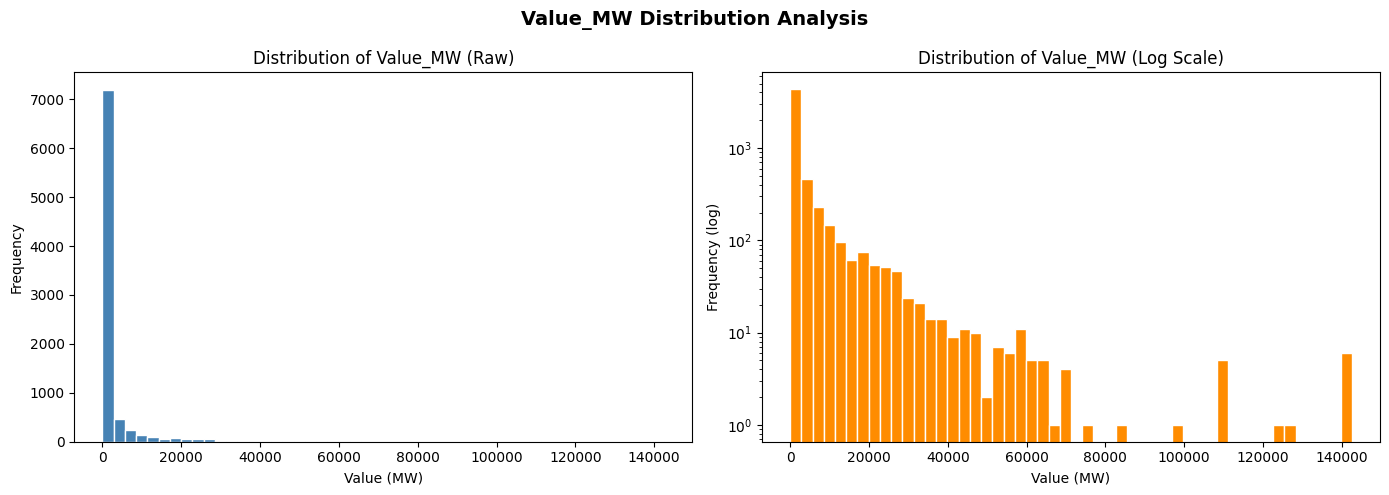

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Value_MW'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Value_MW (Raw)')
axes[0].set_xlabel('Value (MW)')
axes[0].set_ylabel('Frequency')

# Log-scale histogram (better view since data is right-skewed)
axes[1].hist(df[df['Value_MW'] > 0]['Value_MW'], bins=50,
             color='darkorange', edgecolor='white', log=True)
axes[1].set_title('Distribution of Value_MW (Log Scale)')
axes[1].set_xlabel('Value (MW)')
axes[1].set_ylabel('Frequency (log)')

plt.suptitle('Value_MW Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# NOTE: Outliers are NOT removed — large values like 142,560 MW represent
# real national-level aggregates (e.g., 'World' or country totals).
# Removing them would distort the analysis.


# Handling Duplicates

In [21]:
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')

if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed {dups} duplicate rows')
else:
    print('No duplicates found — dataset is clean on this front')

Duplicate rows: 0
No duplicates found — dataset is clean on this front


In [22]:
#Final Dataset
df

,State,Year,Region,Value_Type,Energy_Source,Nature,Usage_Type,Sector,Value_MW
0,ANDAMAN AND NICOBAR ISLANDS,2020,ER,CAPACITY,SMALL HYDRO,RENEWABLE,UNSPECIFIED,UNSPECIFIED,5.25
1,ANDAMAN AND NICOBAR ISLANDS,2020,ER,CAPACITY,SOLAR,RENEWABLE,UNSPECIFIED,UNSPECIFIED,12.19
2,ANDAMAN AND NICOBAR ISLANDS,2020,ER,POTENTIAL,SMALL HYDRO,RENEWABLE,UNSPECIFIED,UNSPECIFIED,7.27
3,ANDAMAN AND NICOBAR ISLANDS,2020,ER,POTENTIAL,WIND,RENEWABLE,UNSPECIFIED,UNSPECIFIED,1277.00
4,ANDAMAN AND NICOBAR ISLANDS,2020,UNKNOWN,GENERATION,BIOMASS-BAGASSE,RENEWABLE,UTILITY,UTILITY-RE,0.00
...,...,...,...,...,...,...,...,...,...
8571,WEST BENGAL,2006,UNKNOWN,GENERATION,DIESEL,NON-RENEWABLE,CAPTIVE,CAPTIVE,74.36
8572,WEST BENGAL,2006,UNKNOWN,GENERATION,HYDRO,NON-RENEWABLE,CAPTIVE,CAPTIVE,0.00
8573,WEST BENGAL,2006,UNKNOWN,GENERATION,HYDRO,NON-RENEWABLE,UTILITY,STATE,468.21
8574,WEST BENGAL,2006,UNKNOWN,GENERATION,NATURAL GAS,NON-RENEWABLE,CAPTIVE,CAPTIVE,0.00


# Univariate Analysis

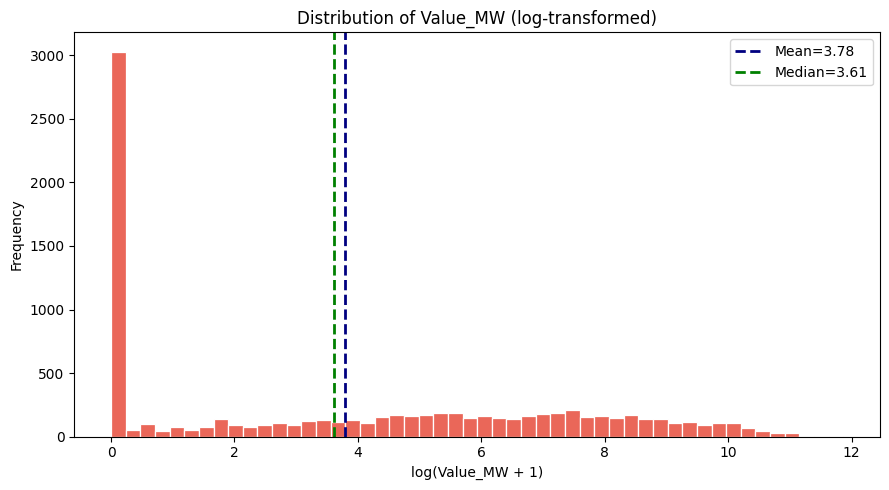

In [23]:
log_vals = np.log1p(df["Value_MW"])

plt.figure(figsize=(9,5))
sns.histplot(log_vals, bins=50, color="#e74c3c", edgecolor="white", alpha=0.85)
plt.axvline(log_vals.mean(), color="navy", ls="--", lw=2, label=f"Mean={log_vals.mean():.2f}")
plt.axvline(log_vals.median(), color="green", ls="--", lw=2, label=f"Median={log_vals.median():.2f}")
plt.title("Distribution of Value_MW (log-transformed)")
plt.xlabel("log(Value_MW + 1)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
vals = pd.to_numeric(df["Value_MW"], errors="coerce").dropna()
year_vals = pd.to_numeric(df["Year"], errors="coerce").dropna()

print("=" * 60)
print("UNIVARIATE STATISTICS - Value_MW")
print("=" * 60)
print(vals.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]).round(3))
print(f"Skewness : {vals.skew():.4f}")
print(f"Kurtosis : {vals.kurtosis():.4f}")
print(f"IQR      : {(vals.quantile(0.75) - vals.quantile(0.25)):.3f}")
print(f"CV (%)   : {(vals.std() / vals.mean() * 100):.2f}" if vals.mean() != 0 else "CV (%)   : NA (mean=0)")

print("\n" + "=" * 60)
print("UNIVARIATE STATISTICS - Year")
print("=" * 60)
print(year_vals.describe().round(3))

UNIVARIATE STATISTICS - Value_MW
count     8576.00
mean      2589.54
std       8675.69
min          0.00
25%          0.00
50%         36.11
75%       1022.08
90%       6268.08
95%      15038.90
max     142560.00
Name: Value_MW, dtype: float64
Skewness : 7.5605
Kurtosis : 84.4046
IQR      : 1022.082
CV (%)   : 335.03

UNIVARIATE STATISTICS - Year
count   8576.00
mean    2013.94
std        4.18
min     2006.00
25%     2010.00
50%     2014.00
75%     2018.00
max     2020.00
Name: Year, dtype: float64


CATEGORICAL FREQUENCY TABLES

Nature
               Count  Percent
Nature                       
RENEWABLE       4768    55.60
NON-RENEWABLE   3808    44.40

Value_Type
            Count  Percent
Value_Type                
GENERATION   6784    79.10
CAPACITY     1109    12.93
POTENTIAL     683     7.96

Usage_Type
             Count  Percent
Usage_Type                 
UTILITY       4179    48.73
CAPTIVE       2605    30.38
UNSPECIFIED   1792    20.90

Sector
             Count  Percent
Sector                     
CAPTIVE       2605    30.38
UTILITY-RE    2342    27.31
UNSPECIFIED   1792    20.90
STATE          821     9.57
CENTRAL        611     7.12
PRIVATE        405     4.72

Energy_Source
                      Count  Percent
Energy_Source                       
SOLAR                  1177    13.72
HYDRO                  1116    13.01
COAL                   1105    12.88
WIND                   1023    11.93
SMALL HYDRO            1002    11.68
NATURAL GAS             876    10.21
D

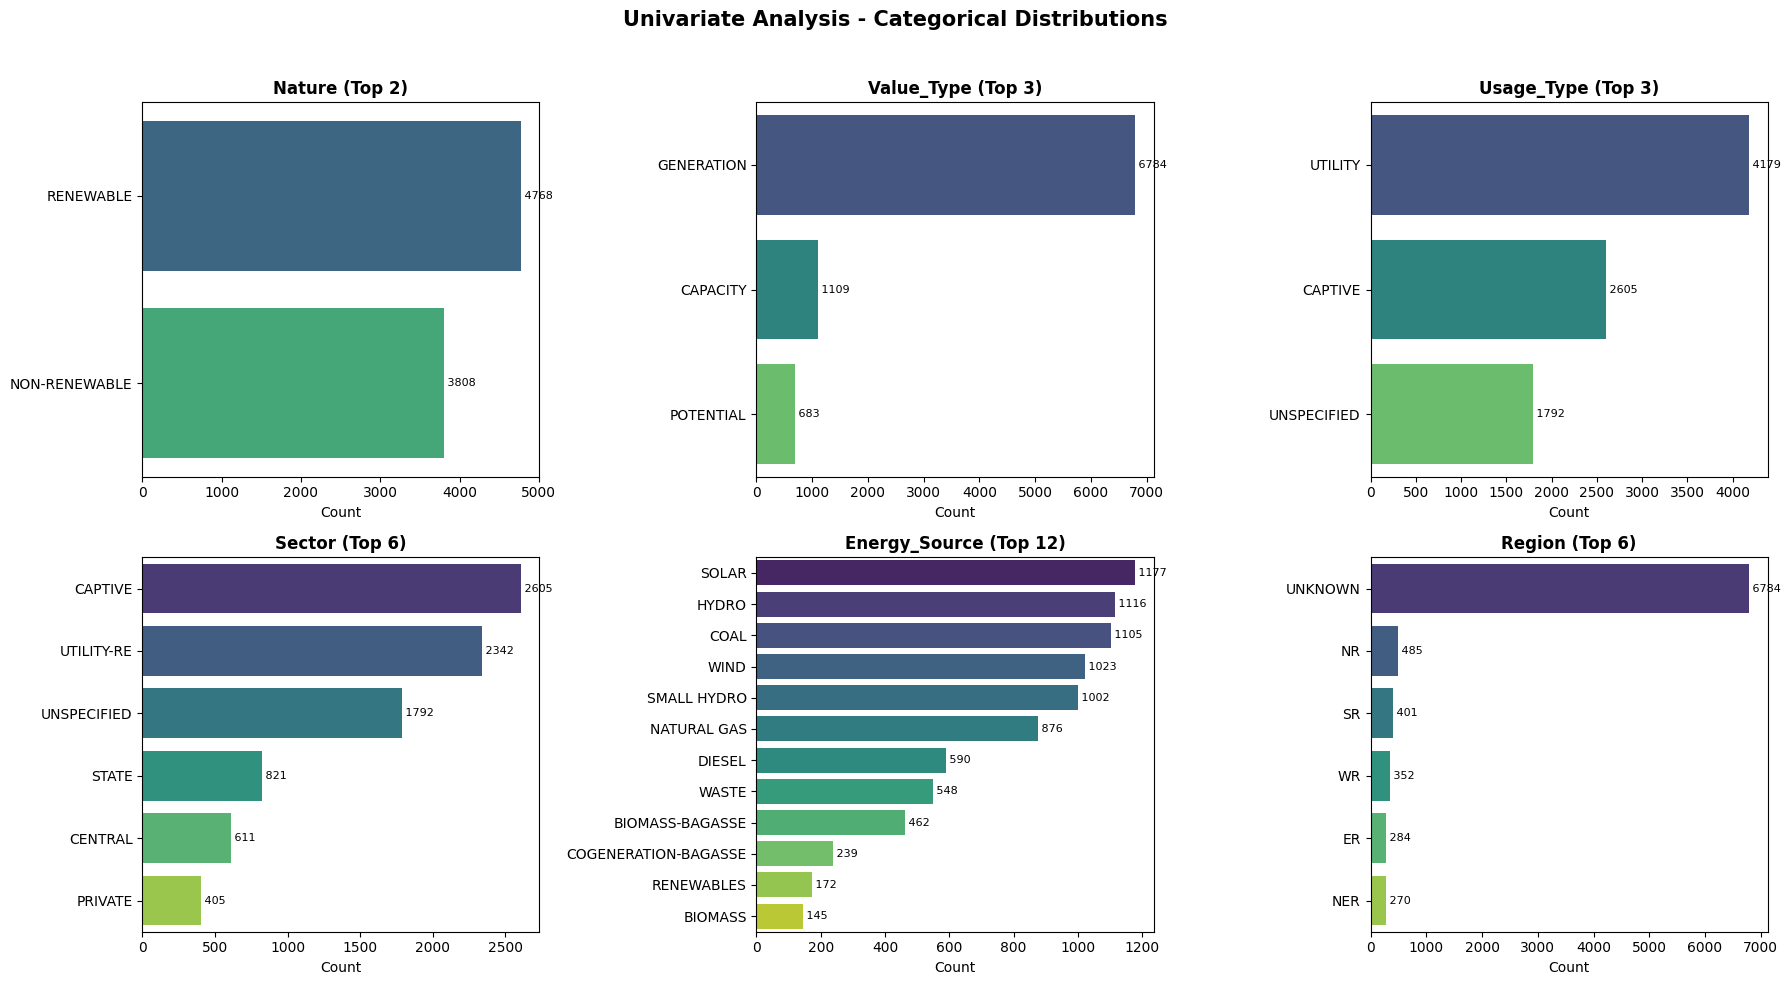

In [25]:
cat_cols = ["Nature", "Value_Type", "Usage_Type", "Sector", "Energy_Source", "Region"]

print("=" * 60)
print("CATEGORICAL FREQUENCY TABLES")
print("=" * 60)

for col in cat_cols:
    vc = df[col].astype(str).value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(2)
    table = pd.DataFrame({"Count": vc, "Percent": pct})
    print(f"\n{col}")
    print(table.head(15))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Univariate Analysis - Categorical Distributions", fontsize=15, fontweight="bold")

for ax, col in zip(axes.flatten(), cat_cols):
    vc = df[col].astype(str).value_counts().head(12)

    plot_df = vc.reset_index()
    plot_df.columns = [col, "Count"]

    sns.barplot(
        data=plot_df,
        x="Count",
        y=col,
        hue=col,            
        palette="viridis",
        dodge=False,
        legend=False,
        ax=ax
    )

    ax.set_title(f"{col} (Top {len(vc)})", fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    for i, v in enumerate(plot_df["Count"]):
        ax.text(v, i, f" {v}", va="center", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("fig03_categorical_distributions.png", bbox_inches="tight")
plt.show()

# Bivariate Analysis

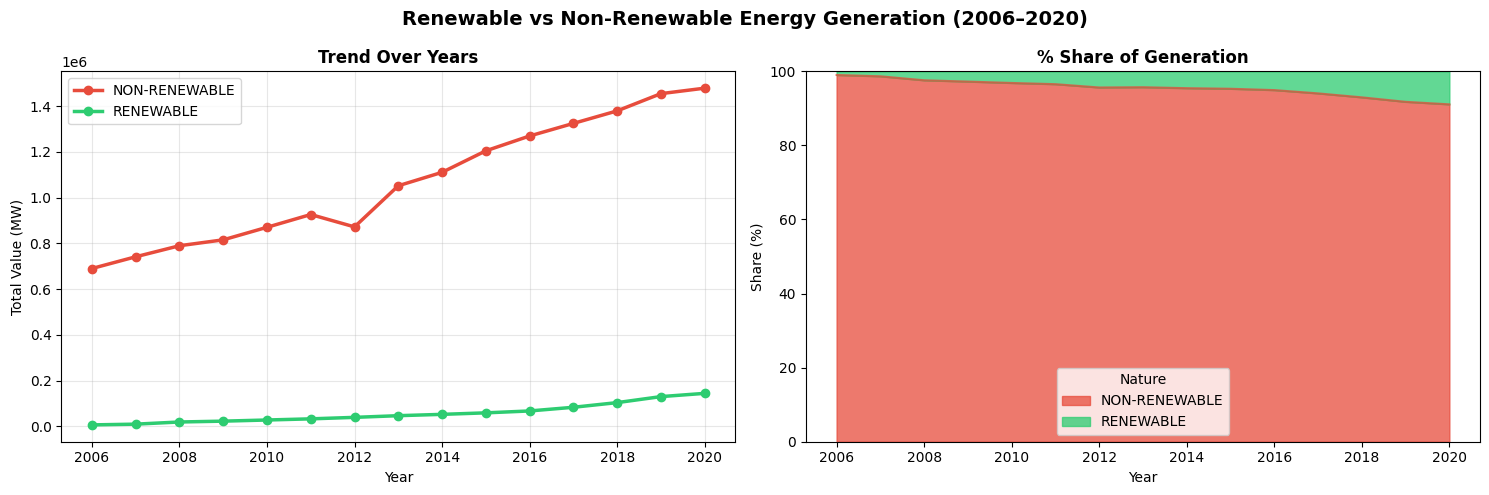


Renewable generation growth from 2006 to 2020: 2007.5%


In [26]:
gen_df = df[df['Value_Type'] == 'GENERATION']

yearly_nature = (gen_df.groupby(['Year','Nature'])['Value_MW']
                 .sum().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Renewable vs Non-Renewable Energy Generation (2006–2020)',
             fontsize=14, fontweight='bold')

colors = {'RENEWABLE': '#2ecc71', 'NON-RENEWABLE': '#e74c3c'}
for nature, grp in yearly_nature.groupby('Nature'):
    axes[0].plot(grp['Year'], grp['Value_MW'], marker='o', lw=2.5,
                 label=nature, color=colors.get(nature, 'gray'))

axes[0].set_xlabel('Year'); axes[0].set_ylabel('Total Value (MW)')
axes[0].set_title('Trend Over Years', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# % share stacked area
pivot = yearly_nature.pivot(index='Year', columns='Nature', values='Value_MW').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='area', stacked=True, ax=axes[1],
               color=['#e74c3c','#2ecc71'], alpha=0.75)
axes[1].set_title('% Share of Generation', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Share (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('fig04_renewable_vs_nonrenewable.png', bbox_inches='tight')
plt.show()

# Print renewable growth rate
ren = yearly_nature[yearly_nature['Nature']=='RENEWABLE'].set_index('Year')['Value_MW']
growth = ((ren.iloc[-1] - ren.iloc[0]) / ren.iloc[0]) * 100
print(f"\nRenewable generation growth from {ren.index[0]} to {ren.index[-1]}: {growth:.1f}%")


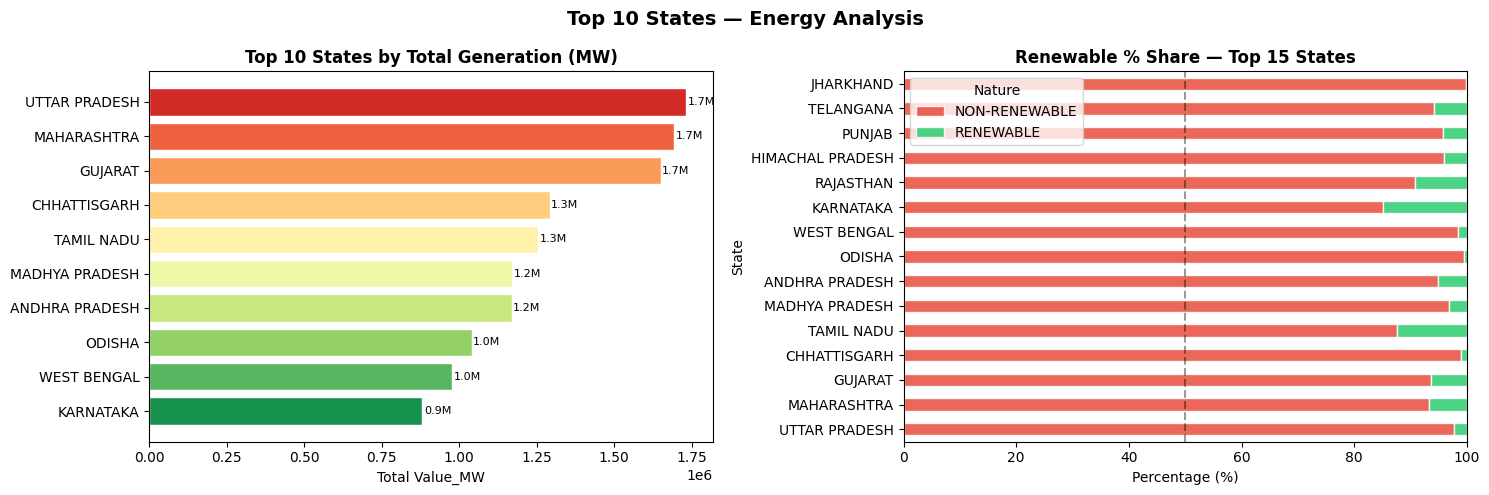

In [27]:
gen_df = df[df['Value_Type'] == 'GENERATION']
state_gen = gen_df.groupby('State')['Value_MW'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Top 10 States — Energy Analysis', fontsize=14, fontweight='bold')

# Total generation
colors_bar = sns.color_palette('RdYlGn', 10)[::-1]
bars = axes[0].barh(state_gen.index[::-1], state_gen.values[::-1],
                    color=colors_bar, edgecolor='white')
axes[0].set_title('Top 10 States by Total Generation (MW)', fontweight='bold')
axes[0].set_xlabel('Total Value_MW')
for bar, val in zip(bars, state_gen.values[::-1]):
    axes[0].text(val + 5000, bar.get_y() + bar.get_height()/2,
                 f'{val/1e6:.1f}M', va='center', fontsize=8)

# Renewable % per state (top 15 states)
state_nature = (gen_df.groupby(['State','Nature'])['Value_MW'].sum()
                .unstack(fill_value=0))
state_nature['Total'] = state_nature.sum(axis=1)
top_states = state_nature.nlargest(15, 'Total').drop(columns='Total')
top_states_pct = top_states.div(top_states.sum(axis=1), axis=0) * 100

top_states_pct.plot(kind='barh', stacked=True, ax=axes[1],
                    color=['#e74c3c','#2ecc71'], edgecolor='white', alpha=0.85)
axes[1].set_title('Renewable % Share — Top 15 States', fontweight='bold')
axes[1].set_xlabel('Percentage (%)')
axes[1].set_xlim(0, 100)
axes[1].axvline(50, color='black', ls='--', alpha=0.4)
axes[1].legend(title='Nature')

plt.tight_layout()
plt.savefig('fig05_top_states.png', bbox_inches='tight')
plt.show()


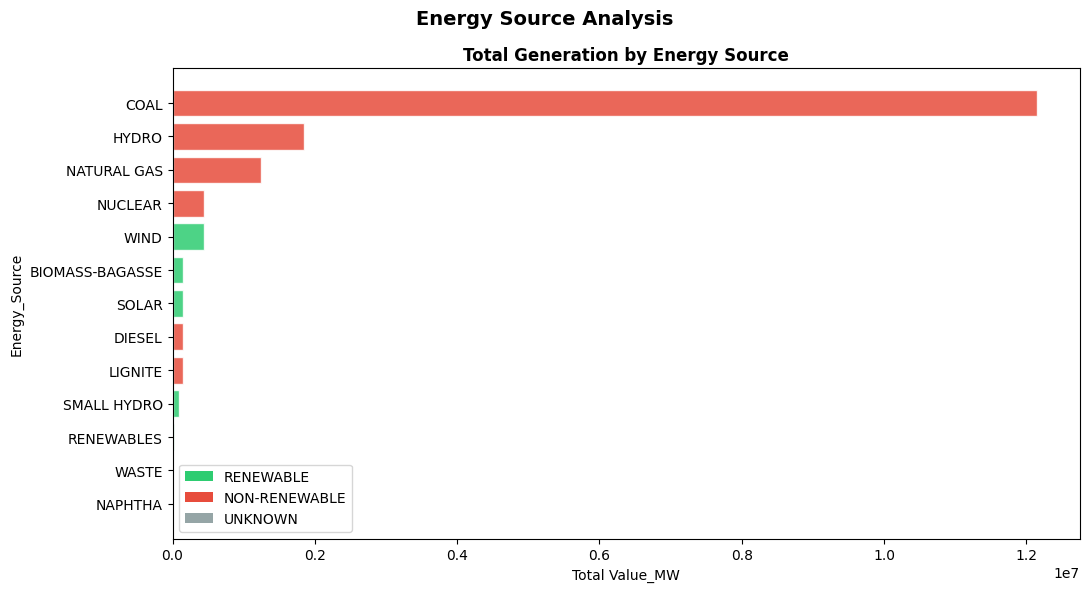

In [28]:
source_gen = (df[df['Value_Type'] == 'GENERATION']
.groupby(['Energy_Source', 'Nature'])['Value_MW']
.sum()
.reset_index()
.sort_values('Value_MW', ascending=True))

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle('Energy Source Analysis', fontsize=14, fontweight='bold')

pal = {'RENEWABLE': '#2ecc71', 'NON-RENEWABLE': '#e74c3c', 'UNKNOWN': '#95a5a6'}
colors_src = [pal.get(n, '#3c4242') for n in source_gen['Nature']]

ax.barh(source_gen['Energy_Source'], source_gen['Value_MW'],
color=colors_src, edgecolor='white', alpha=0.85)

ax.set_title('Total Generation by Energy Source', fontweight='bold')
ax.set_xlabel('Total Value_MW')
ax.set_ylabel('Energy_Source')

from matplotlib.patches import Patch
legend_elements = [
Patch(facecolor='#2ecc71', label='RENEWABLE'),
Patch(facecolor='#e74c3c', label='NON-RENEWABLE'),
Patch(facecolor='#95a5a6', label='UNKNOWN')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('fig06_energy_sources.png', bbox_inches='tight')
plt.show()

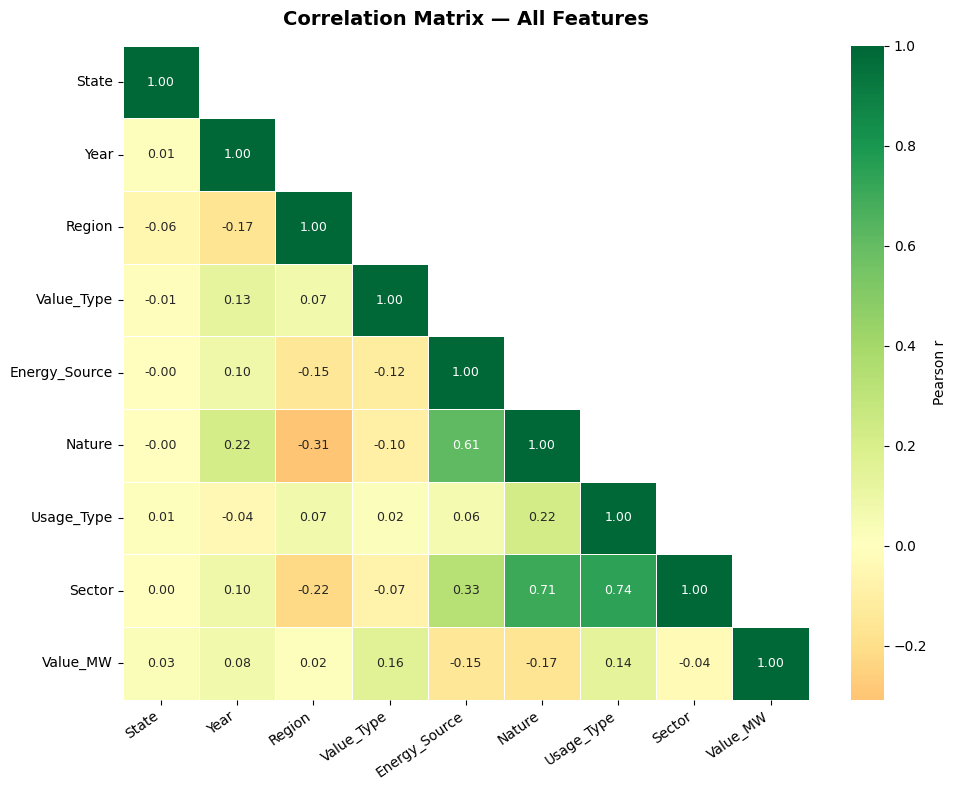

In [29]:
# Encode categoricals numerically for correlation
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()
for col in ['State','Region','Value_Type','Energy_Source','Nature','Usage_Type','Sector']:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, linecolor='white',
            mask=mask, annot_kws={'size': 9},
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix — All Features', fontweight='bold', fontsize=14, pad=15)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('fig07_correlation_heatmap.png', bbox_inches='tight')
plt.show()


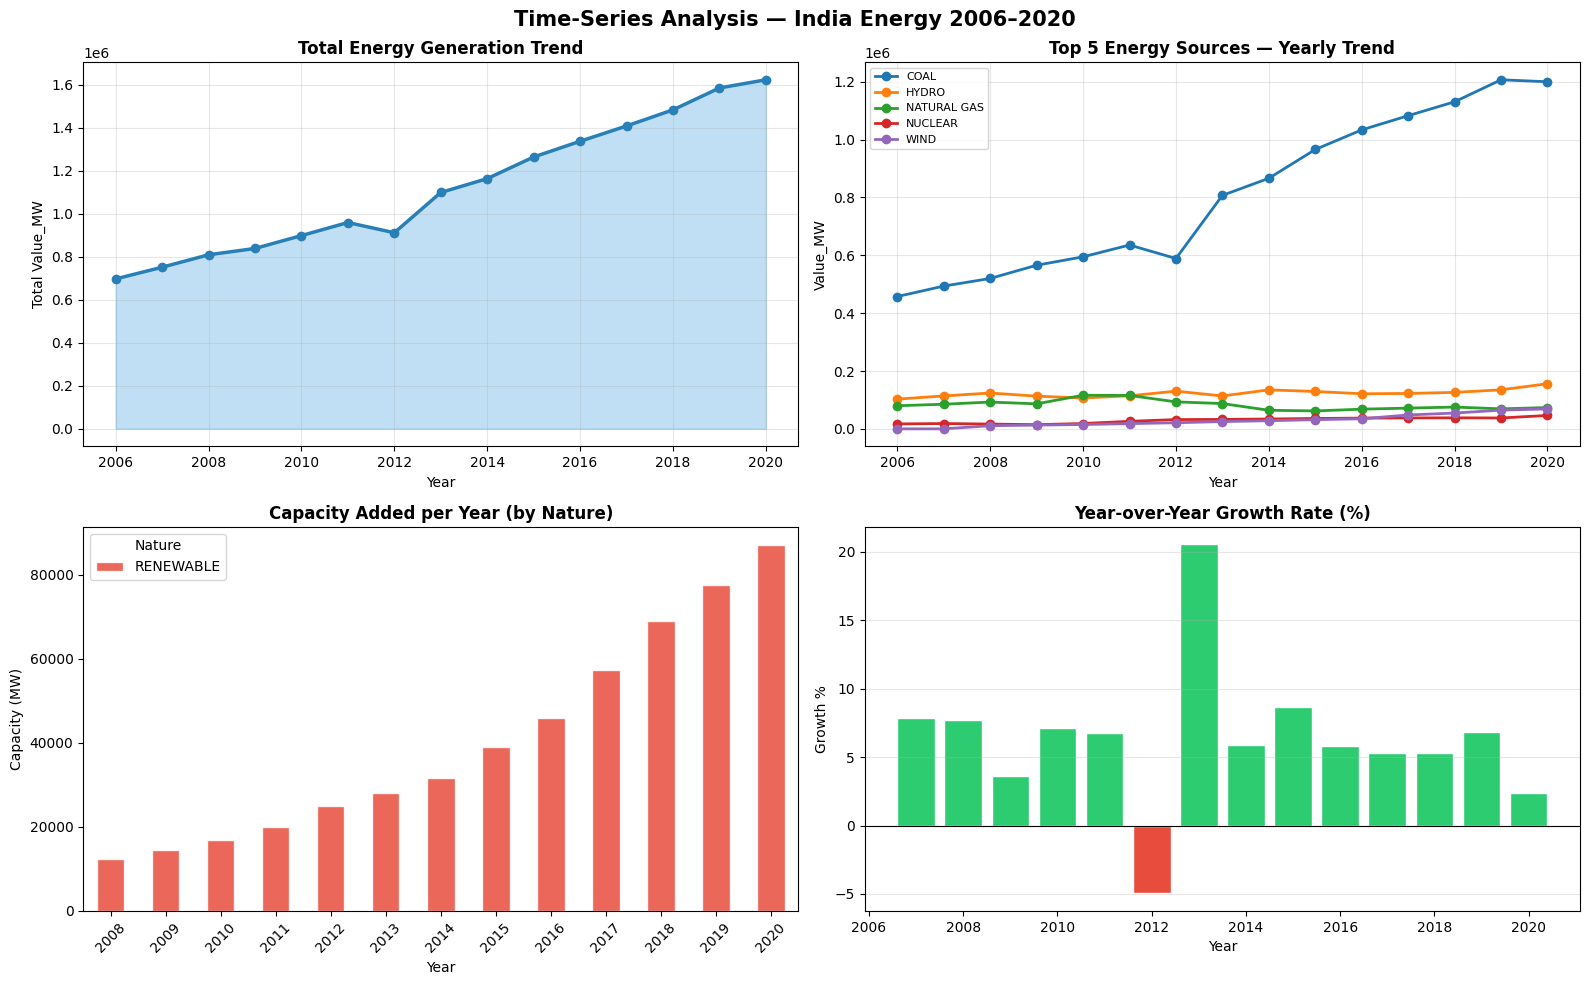

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time-Series Analysis — India Energy 2006–2020', fontsize=15, fontweight='bold')

gen = df[df['Value_Type'] == 'GENERATION']
cap = df[df['Value_Type'] == 'CAPACITY']

# Total generation trend
yearly_total = gen.groupby('Year')['Value_MW'].sum()
axes[0,0].fill_between(yearly_total.index, yearly_total.values, alpha=0.3, color='#3498db')
axes[0,0].plot(yearly_total.index, yearly_total.values, marker='o', color='#2980b9', lw=2.5)
axes[0,0].set_title('Total Energy Generation Trend', fontweight='bold')
axes[0,0].set_ylabel('Total Value_MW'); axes[0,0].set_xlabel('Year')
axes[0,0].grid(True, alpha=0.3)

# Source-wise trend (top 5 sources)
top5_src = gen.groupby('Energy_Source')['Value_MW'].sum().nlargest(5).index.tolist()
src_yearly = gen[gen['Energy_Source'].isin(top5_src)].groupby(
    ['Year','Energy_Source'])['Value_MW'].sum().unstack()
src_yearly.plot(ax=axes[0,1], marker='o', lw=2)
axes[0,1].set_title('Top 5 Energy Sources — Yearly Trend', fontweight='bold')
axes[0,1].set_ylabel('Value_MW'); axes[0,1].set_xlabel('Year')
axes[0,1].grid(True, alpha=0.3); axes[0,1].legend(fontsize=8)

# Capacity added per year
cap_yearly = cap.groupby(['Year','Nature'])['Value_MW'].sum().unstack(fill_value=0)
cap_yearly.plot(kind='bar', ax=axes[1,0], color=['#e74c3c','#2ecc71'], alpha=0.85, edgecolor='white')
axes[1,0].set_title('Capacity Added per Year (by Nature)', fontweight='bold')
axes[1,0].set_ylabel('Capacity (MW)'); axes[1,0].set_xlabel('Year')
axes[1,0].legend(title='Nature'); axes[1,0].tick_params(axis='x', rotation=45)

# YoY growth rate
yoy = yearly_total.pct_change() * 100
colors_yoy = ['#2ecc71' if v >= 0 else '#e74c3c' for v in yoy.dropna()]
axes[1,1].bar(yoy.dropna().index, yoy.dropna().values, color=colors_yoy, edgecolor='white')
axes[1,1].axhline(0, color='black', lw=0.8)
axes[1,1].set_title('Year-over-Year Growth Rate (%)', fontweight='bold')
axes[1,1].set_ylabel('Growth %'); axes[1,1].set_xlabel('Year')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig09_timeseries.png', bbox_inches='tight')
plt.show()


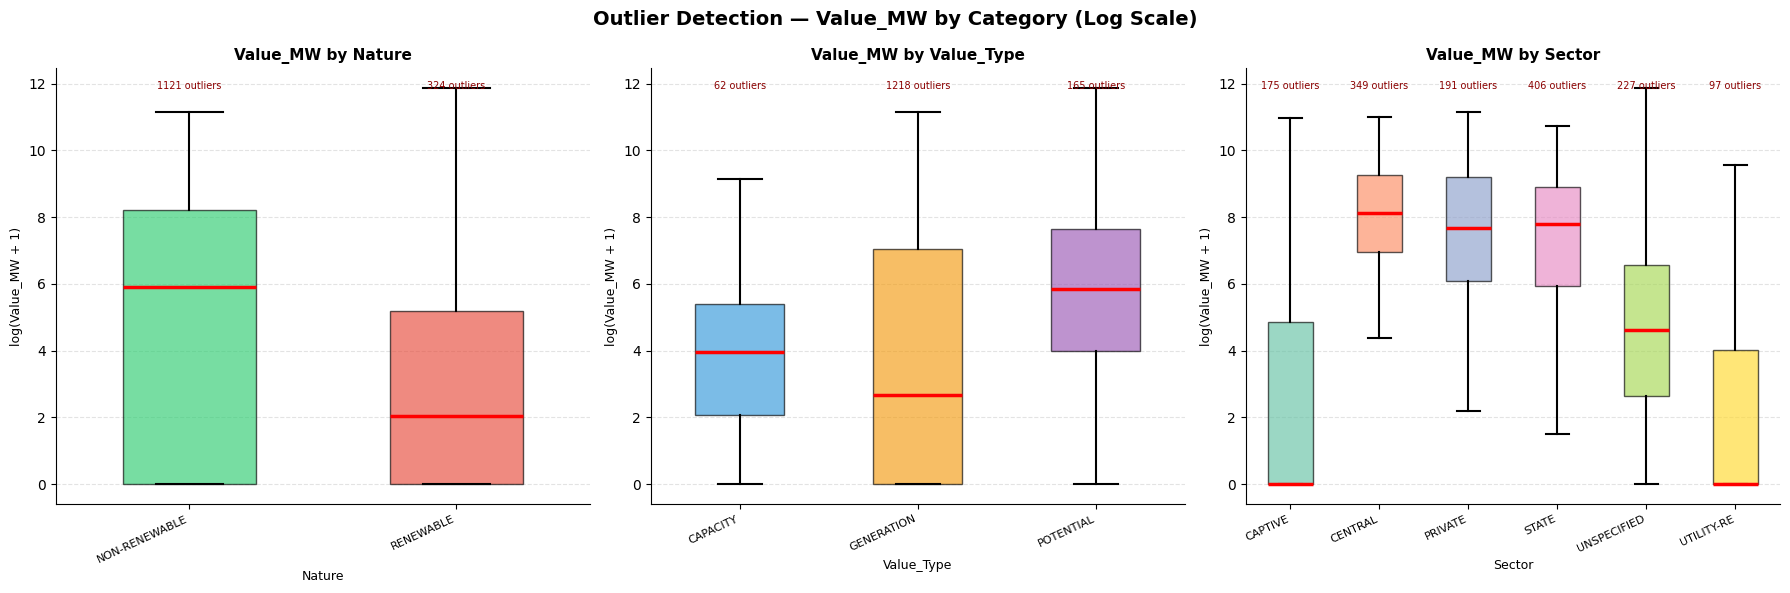

Global IQR fence: 2,555.21 MW
Outlier rows: 1445 (16.8%) — kept as real state aggregates.


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Outlier Detection — Value_MW by Category (Log Scale)', fontsize=14, fontweight='bold')

groups_info = [
    ('Nature',     ['#2ecc71', '#e74c3c']),
    ('Value_Type', ['#3498db', '#f39c12', '#9b59b6']),
    ('Sector',     list(sns.color_palette('Set2', 6))),
]

Q1, Q3 = df['Value_MW'].quantile(0.25), df['Value_MW'].quantile(0.75)
fence = Q3 + 1.5 * (Q3 - Q1)

for ax, (col, palette) in zip(axes, groups_info):
    categories = sorted(df[col].unique())

    # log1p transform — prevents zeros from collapsing boxes & makes outliers visible
    plot_data = [np.log1p(df[df[col] == c]['Value_MW'].values) for c in categories]

    bp = ax.boxplot(plot_data, tick_labels=categories, patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='red', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', alpha=0.2, markersize=3, markeredgewidth=0))

    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    # annotate outlier count above each box
    for i, c in enumerate(categories):
        n_out = (df[df[col] == c]['Value_MW'] > fence).sum()
        ax.text(i + 1, ax.get_ylim()[1] * 0.97, f'{n_out} outliers',
                ha='center', va='top', fontsize=7, color='darkred')

    ax.set_title(f'Value_MW by {col}', fontweight='bold', fontsize=11)
    ax.set_ylabel('log(Value_MW + 1)', fontsize=9)
    ax.set_xlabel(col, fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.35, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_outlier_boxplots.png', bbox_inches='tight', dpi=130)
plt.show()

print(f"Global IQR fence: {fence:,.2f} MW")
n_out = (df['Value_MW'] > fence).sum()
print(f"Outlier rows: {n_out} ({n_out/len(df)*100:.1f}%) — kept as real state aggregates.")

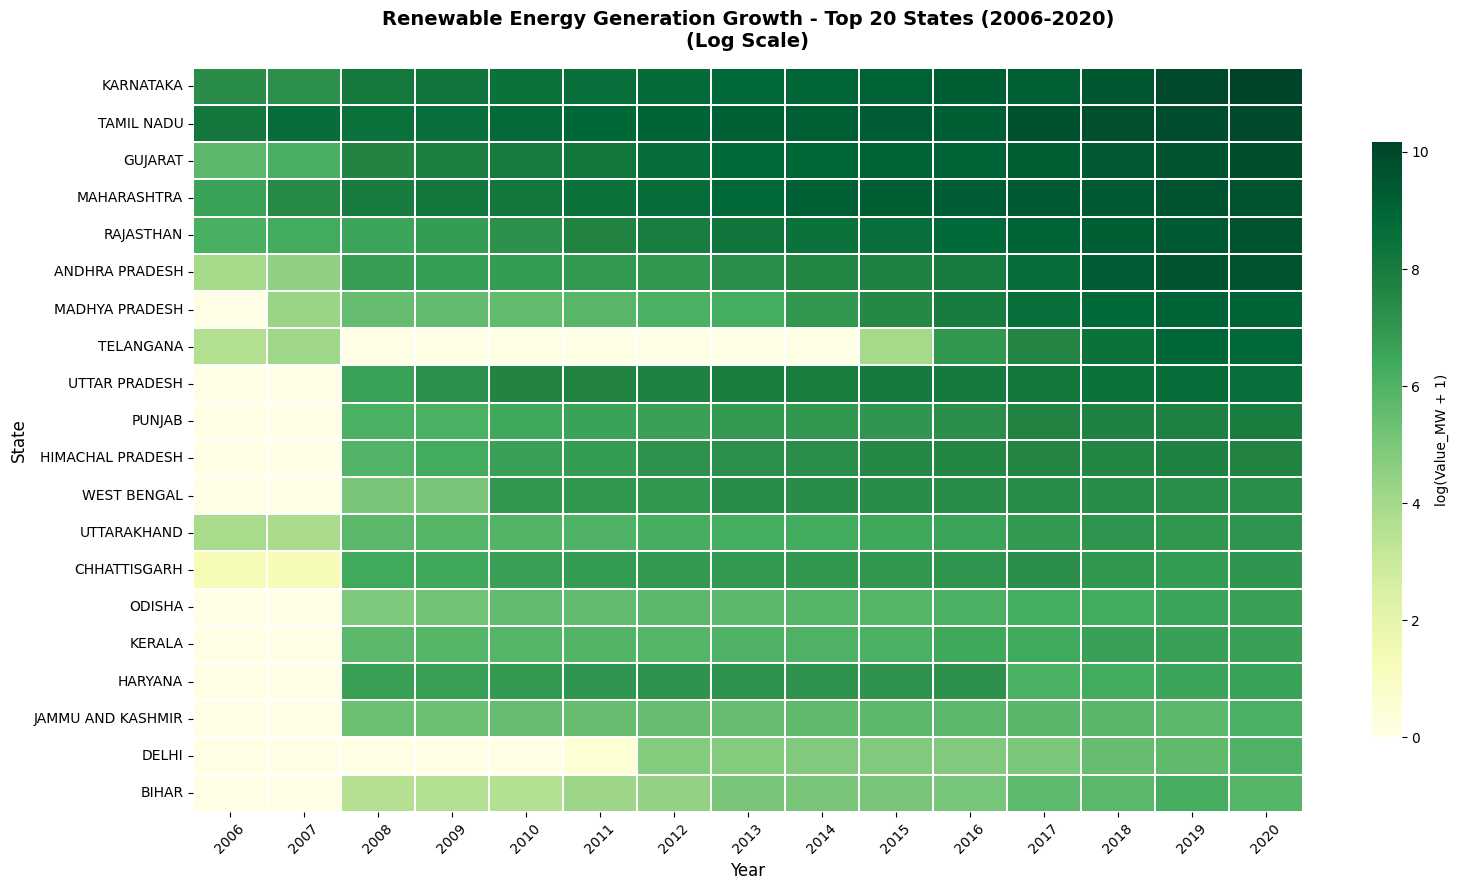

In [32]:
# Heatmap: State × Year — Renewable Generation (log scale)
ren_gen = (df[(df['Nature']=='RENEWABLE') & (df['Value_Type']=='GENERATION')]
           .groupby(['State','Year'])['Value_MW'].sum()
           .unstack(fill_value=0))

# Keep states with at least some renewable data
ren_gen = ren_gen[ren_gen.sum(axis=1) > 0].sort_values(ren_gen.columns[-1], ascending=False).head(20)

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(np.log1p(ren_gen), ax=ax, cmap='YlGn',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'log(Value_MW + 1)', 'shrink': 0.8},
            annot=False)
ax.set_title(
    "Renewable Energy Generation Growth - Top 20 States (2006-2020)\n(Log Scale)",
    fontweight="bold",
    fontsize=14,
    pad=15
)
ax.set_xlabel('Year', fontsize=12); ax.set_ylabel('State', fontsize=12)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fig10_renewable_heatmap.png', bbox_inches='tight')
plt.show()


In [33]:
import panel as pn
import hvplot.pandas

pn.extension('tabulator')

# ── Widgets ──────────────────────────────────────────────────────────────────
year_slider = pn.widgets.RangeSlider(
    name='Year Range',
    start=df['Year'].min(), end=df['Year'].max(),
    value=(df['Year'].min(), df['Year'].max()), step=1
)
nature_select = pn.widgets.RadioButtonGroup(
    name='Nature', options=['ALL', 'RENEWABLE', 'NON-RENEWABLE'],
    value='ALL', button_type='success'
)
value_type_select = pn.widgets.RadioButtonGroup(
    name='Value Type', options=['GENERATION', 'CAPACITY', 'POTENTIAL'],
    value='GENERATION', button_type='primary'
)
state_select = pn.widgets.MultiSelect(
    name='States (Ctrl = multi-select)',
    options=sorted(df['State'].unique().tolist()),
    value=sorted(df['State'].unique().tolist())[:10],
    size=8
)
print("✅ Widgets ready")

✅ Widgets ready


In [34]:
# ── Plot 1 — Yearly Trend ────────────────────────────────────────────────────
def make_trend_plot(year_start, year_end, value_type):
    filtered = df[
        (df['Year'] >= year_start) &
        (df['Year'] <= year_end) &
        (df['Value_Type'] == value_type)
    ]
    return (
        filtered
        .groupby(['Year', 'Nature'])['Value_MW'].sum()
        .reset_index()
        .sort_values('Year')
        .hvplot(
            x='Year', y='Value_MW', by='Nature',
            color=['#e74c3c', '#2ecc71'],
            line_width=2.5, markers=True,
            title='⚡ Yearly Energy Trend by Nature',
            ylabel='Total Value (MW)', xlabel='Year',
            legend='top_left', height=300, width=520
        )
    )

trend_plot = pn.bind(make_trend_plot,
                     year_slider.param.value_start,
                     year_slider.param.value_end,
                     value_type_select)

In [35]:
# ── Plot 2 — Top States Bar ──────────────────────────────────────────────────
def make_state_bar(year_start, year_end, value_type):
    filtered = df[
        (df['Year'] >= year_start) &
        (df['Year'] <= year_end) &
        (df['Value_Type'] == value_type)
    ]
    return (
        filtered
        .groupby('State')['Value_MW'].sum()
        .reset_index()
        .sort_values('Value_MW', ascending=False)
        .head(12)
        .hvplot.bar(
            x='State', y='Value_MW',
            color='#3498db', alpha=0.85,
            title='🏆 Top 12 States by Energy Value',
            ylabel='Total Value (MW)', xlabel='State',
            rot=45, height=300, width=520
        )
    )

state_bar_plot = pn.bind(make_state_bar,
                          year_slider.param.value_start,
                          year_slider.param.value_end,
                          value_type_select)

In [36]:
# ── Plot 3 — Energy Source Bar ───────────────────────────────────────────────
def make_source_bar(year_start, year_end, value_type):
    filtered = df[
        (df['Year'] >= year_start) &
        (df['Year'] <= year_end) &
        (df['Value_Type'] == value_type)
    ]
    return (
        filtered
        .groupby(['Energy_Source', 'Nature'])['Value_MW'].sum()
        .reset_index()
        .sort_values('Value_MW', ascending=False)
        .hvplot.bar(
            x='Energy_Source', y='Value_MW',
            by='Nature', color=['#e74c3c', '#2ecc71'],
            stacked=False, alpha=0.85,
            title='🔋 Generation by Energy Source',
            ylabel='Total Value (MW)', xlabel='Energy Source',
            rot=45, height=300, width=520,
            legend='top_right'
        )
    )

source_bar_plot = pn.bind(make_source_bar,
                           year_slider.param.value_start,
                           year_slider.param.value_end,
                           value_type_select)

In [37]:
# ── Plot 4 — Stacked Area ────────────────────────────────────────────────────
def make_area_plot(year_start, year_end):
    filtered = df[
        (df['Year'] >= year_start) &
        (df['Year'] <= year_end) &
        (df['Value_Type'] == 'GENERATION')
    ]
    return (
        filtered
        .groupby(['Year', 'Nature'])['Value_MW'].sum()
        .reset_index()
        .hvplot.area(
            x='Year', y='Value_MW', by='Nature',
            stacked=True, color=['#e74c3c', '#2ecc71'],
            alpha=0.75,
            title='📊 Stacked Generation Share (MW)',
            ylabel='Value (MW)', xlabel='Year',
            height=300, width=520, legend='top_left'
        )
    )

share_area_plot = pn.bind(make_area_plot,
                           year_slider.param.value_start,
                           year_slider.param.value_end)

In [38]:
# ── Plot 5 — State Scatter ───────────────────────────────────────────────────
def make_scatter(year_start, year_end, value_type, states):
    filtered = df[
        (df['Year'] >= year_start) &
        (df['Year'] <= year_end) &
        (df['Value_Type'] == value_type) &
        (df['State'].isin(states))
    ]
    return (
        filtered
        .groupby(['State', 'Nature'])['Value_MW'].sum()
        .reset_index()
        .hvplot.scatter(
            x='State', y='Value_MW',
            by='Nature', size=60,
            color=['#e74c3c', '#2ecc71'],
            alpha=0.65, legend='top_right',
            title='🔍 State vs Value_MW by Nature',
            xlabel='State', ylabel='Value (MW)',
            rot=45, height=300, width=520
        )
    )

scatter_plot = pn.bind(make_scatter,
                        year_slider.param.value_start,
                        year_slider.param.value_end,
                        value_type_select,
                        state_select)

In [39]:
# ── Plot 6 — Data Table ──────────────────────────────────────────────────────
def make_table(year_start, year_end, value_type, states):
    filtered = df[
        (df['Year'] >= year_start) &
        (df['Year'] <= year_end) &
        (df['Value_Type'] == value_type) &
        (df['State'].isin(states))
    ][['State', 'Year', 'Energy_Source', 'Nature', 'Sector', 'Value_MW']]
    return filtered.sort_values('Value_MW', ascending=False).reset_index(drop=True)

data_table = pn.widgets.Tabulator(
    make_table(df['Year'].min(), df['Year'].max(), 'GENERATION',
               sorted(df['State'].unique().tolist())[:10]),
    pagination='remote', page_size=12,
    sizing_mode='stretch_width', header_filters=True
)

# Wire table to widgets separately
def update_table(event):
    data_table.value = make_table(
        year_slider.param.value_start.rx.value,
        year_slider.param.value_end.rx.value,
        value_type_select.value,
        state_select.value
    )

year_slider.param.watch(update_table, ['value_start', 'value_end'])
value_type_select.param.watch(update_table, 'value')
state_select.param.watch(update_table, 'value')

Watcher(inst=MultiSelect(name='States (Ctrl =..., options=['ANDAMAN AND NICOBAR ISLA...], size=8, value=['ANDAMAN AND NICOBAR ISLA...]), cls=<class 'panel.widgets.select.MultiSelect'>, fn=<function update_table at 0x000002048CF57060>, mode='args', onlychanged=True, parameter_names=('value',), what='value', queued=False, precedence=0)

In [40]:
# ── Final Assembly ───────────────────────────────────────────────────────────
template = pn.template.FastListTemplate(
    title='🇮🇳 India State-wise Energy Dashboard (2006–2020)',
    sidebar=[
        pn.pane.Markdown("# ⚡ India Energy Explorer"),
        pn.pane.Markdown(
            "Explore **state-wise electricity data** across renewable "
            "and non-renewable sources from 2006–2020."
        ),
        pn.pane.Markdown("---\n## 🎛️ Filters"),
        pn.pane.Markdown("**Year Range**"),    year_slider,
        pn.pane.Markdown("**Value Type**"),    value_type_select,
        pn.pane.Markdown("**Nature**"),        nature_select,
        pn.pane.Markdown("**Select States**"), state_select,
    ],
    main=[
        pn.Row(
            pn.Column(pn.pane.Markdown("### ⚡ Yearly Trend"),
                      pn.panel(trend_plot,      width=520), margin=(0, 20)),
            pn.Column(pn.pane.Markdown("### 🏆 Top States"),
                      pn.panel(state_bar_plot,  width=520))
        ),
        pn.Row(
            pn.Column(pn.pane.Markdown("### 🔋 By Energy Source"),
                      pn.panel(source_bar_plot, width=520), margin=(0, 20)),
            pn.Column(pn.pane.Markdown("### 📊 Stacked Share"),
                      pn.panel(share_area_plot, width=520))
        ),
        pn.Row(
            pn.Column(pn.pane.Markdown("### 🔍 State Scatter"),
                      pn.panel(scatter_plot,    width=520), margin=(0, 20)),
            pn.Column(pn.pane.Markdown("### 📋 Data Table"),
                      data_table)
        ),
    ],
    accent_base_color='#2ecc71',
    header_background='#27ae60',
)

template.show()

Launching server at http://localhost:49686
